<a href="https://www.kaggle.com/code/zakiyff/prediction-wine-reviews?scriptVersionId=301837005" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/zynicide/wine-reviews/winemag-data_first150k.csv
/kaggle/input/datasets/zynicide/wine-reviews/winemag-data-130k-v2.json
/kaggle/input/datasets/zynicide/wine-reviews/winemag-data-130k-v2.csv


# 1. Preparation
## 1.1. Library

In [2]:
import numpy as np
import pandas as pd 
import seaborn as sns
import matplotlib.pyplot as plt 

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.linear_model import Ridge


## 1.2. Data Acq.

In [3]:
df1 = pd.read_csv("/kaggle/input/datasets/zynicide/wine-reviews/winemag-data_first150k.csv")
df2 = pd.read_csv("/kaggle/input/datasets/zynicide/wine-reviews/winemag-data-130k-v2.csv")
print(f'150k Df Shape : {df1.shape}')
print(f'130k Df Shape : {df2.shape}')

150k Df Shape : (150930, 11)
130k Df Shape : (129971, 14)


Concat 2 dataframe (130k & 150k).

In [4]:
df = pd.concat([df1, df2], axis = 0)
print(f'Concat Df Shape : {df.shape}')

Concat Df Shape : (280901, 14)


# 2. Exploratory Data Analysis (EDA)
## 2.1. Data Sample 

In [5]:
df.head()

,Unnamed: 0,country,description,designation,points,price,province,region_1,region_2,variety,winery,taster_name,taster_twitter_handle,title
0,0,US,This tremendous 100% varietal wine hails from ...,Martha's Vineyard,96,235.0,California,Napa Valley,Napa,Cabernet Sauvignon,Heitz,NaN,NaN,NaN
1,1,Spain,"Ripe aromas of fig, blackberry and cassis are ...",Carodorum Selección Especial Reserva,96,110.0,Northern Spain,Toro,NaN,Tinta de Toro,Bodega Carmen Rodríguez,NaN,NaN,NaN
2,2,US,Mac Watson honors the memory of a wine once ma...,Special Selected Late Harvest,96,90.0,California,Knights Valley,Sonoma,Sauvignon Blanc,Macauley,NaN,NaN,NaN
3,3,US,"This spent 20 months in 30% new French oak, an...",Reserve,96,65.0,Oregon,Willamette Valley,Willamette Valley,Pinot Noir,Ponzi,NaN,NaN,NaN
4,4,France,"This is the top wine from La Bégude, named aft...",La Brûlade,95,66.0,Provence,Bandol,NaN,Provence red blend,Domaine de la Bégude,NaN,NaN,NaN


## 2.2. Dataset Summary 
Total row is : 280.901.

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 280901 entries, 0 to 129970
Data columns (total 14 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   Unnamed: 0             280901 non-null  int64  
 1   country                280833 non-null  object 
 2   description            280901 non-null  object 
 3   designation            197701 non-null  object 
 4   points                 280901 non-null  int64  
 5   price                  258210 non-null  float64
 6   province               280833 non-null  object 
 7   region_1               234594 non-null  object 
 8   region_2               111464 non-null  object 
 9   variety                280900 non-null  object 
 10  winery                 280901 non-null  object 
 11  taster_name            103727 non-null  object 
 12  taster_twitter_handle  98758 non-null   object 
 13  title                  129971 non-null  object 
dtypes: float64(1), int64(2), object(11)
memor

## 2.3. Descriptive Statistics 

In [7]:
df.describe()

,Unnamed: 0,points,price
count,280901.000000,280901.000000,258210.000000
mean,70615.705960,88.146934,34.177162
std,41214.379445,3.151528,38.611708
min,0.000000,80.000000,4.000000
25%,35112.000000,86.000000,16.000000
50%,70225.000000,88.000000,25.000000
75%,105337.000000,90.000000,40.000000
max,150929.000000,100.000000,3300.000000


In [8]:
df.describe(include='object')

,country,description,designation,province,region_1,region_2,variety,winery,taster_name,taster_twitter_handle,title
count,280833,280901,197701,280833,234594,111464,280900,280901,103727,98758,129971
unique,50,169430,47239,490,1332,18,756,19186,19,15,118840
top,US,A little bit funky and unsettled when you pop ...,Reserve,California,Napa Valley,Central Coast,Pinot Noir,Williams Selyem,Roger Voss,@vossroger,Gloria Ferrer NV Sonoma Brut Sparkling (Sonoma...
freq,116901,7,4761,80755,10689,24122,27563,585,25514,25514,11


## 2.4. Target Distribution

<Axes: xlabel='points', ylabel='Count'>

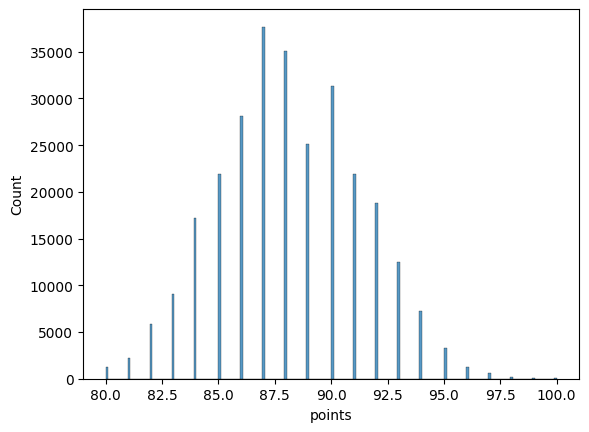

In [9]:
sns.histplot(df['points'])

In [10]:
# Skewness & Kurtosis 
print(f'Skewness : {df["points"].skew()}')
print(f'Kurtosis : {df["points"].kurt()}')

Skewness : 0.08597887115645862
Kurtosis : -0.29702577401586217


## 2.5. Missing Value Check

In [11]:
missing = df.isnull().mean().sort_values(ascending=False)
missing

taster_twitter_handle    0.648424
taster_name              0.630735
region_2                 0.603191
title                    0.537307
designation              0.296190
region_1                 0.164852
price                    0.080779
province                 0.000242
country                  0.000242
variety                  0.000004
points                   0.000000
description              0.000000
Unnamed: 0               0.000000
winery                   0.000000
dtype: float64

## 2.6. Correlation Matrix (number feature)

<Axes: >

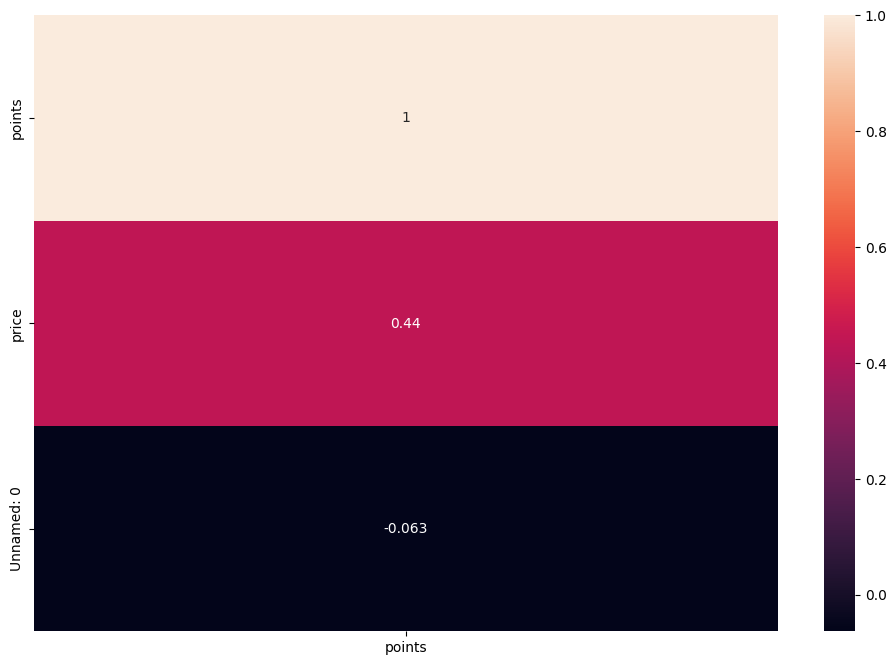

In [12]:
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(numeric_only=True)[["points"]].sort_values(by='points', ascending=False), annot=True)

## 2.7. Unique Value - Country

In [13]:
df['country'].value_counts()

country
US                        116901
France                     43191
Italy                      43018
Spain                      14913
Portugal                   11013
Chile                      10288
Argentina                   9431
Australia                   7286
Austria                     6402
New Zealand                 4739
Germany                     4617
South Africa                3659
Greece                      1350
Israel                      1135
Canada                       453
Hungary                      377
Romania                      259
Bulgaria                     218
Uruguay                      201
Slovenia                     181
Croatia                      162
Turkey                       142
Mexico                       133
Moldova                      130
Georgia                      129
England                       83
Brazil                        77
Lebanon                       72
Cyprus                        42
Morocco                       40
Ma

## 2.8. Frequency Distribution of Categories

In [14]:
df['country'].value_counts().head(10)

country
US             116901
France          43191
Italy           43018
Spain           14913
Portugal        11013
Chile           10288
Argentina        9431
Australia        7286
Austria          6402
New Zealand      4739
Name: count, dtype: int64

minimum of frequency of the 10 largest is 5000.

In [15]:
df['province'].value_counts().head(10)

province
California          80755
Washington          18389
Tuscany             13178
Bordeaux            12052
Oregon               9962
Northern Spain       8743
Burgundy             8288
Mendoza Province     8006
Piedmont             7822
Veneto               6678
Name: count, dtype: int64

In [16]:
df['region_1'].value_counts().head(10)

region_1
Napa Valley               10689
Columbia Valley (WA)       9099
Russian River Valley       6662
California                 6091
Mendoza                    5887
Paso Robles                5403
Willamette Valley          4397
Alsace                     3737
Rioja                      3362
Brunello di Montalcino     3216
Name: count, dtype: int64

In [17]:
df['variety'].value_counts().head(10)

variety
Pinot Noir                  27563
Chardonnay                  26235
Cabernet Sauvignon          22272
Red Blend                   19008
Bordeaux-style Red Blend    14262
Sauvignon Blanc             11287
Riesling                    10713
Syrah                        9967
Merlot                       8172
Zinfandel                    6513
Name: count, dtype: int64

## 2.9. Insight Summary 
Based on EDA that we've done so far : 
1. Country : has 50 unique value
2. Description : high cardinality
3. Designation : high cardinality
4. Points : Target
5. Price : Already has normal distribution
6. Province : has 490 unique value
7. Region_1 : has 1332 unique value
8. Region_2 : has 18 unique value, 60% missing value
9. Variety : has 756 unique value
10. Winery : High cardinality
11. Taster_name : has 19 unique value, 63% missing value
12. Taster_twitter_handle : has 15 unique value, 64% missing value
13. Title : 53% missing value
14. Unnamed: 0 : Index

Actions : 
1. Country : convert to one-hot-encoding (with minimum 1000 freq.)
2. Description : DROP
3. Designation : DROP
4. Points : Scaling the value, cause we'll using simple ML model
5. Price : Scaling the value, cause we'll using simple ML model
6. Province : Convert to one-hot-encoding (with minimum 1000 freq.)
7. Region_1 : Convert to one-hot-encoding (with minimum 1000 freq.)
8. Region_2 : DROP
9. Variety : Convert to one-hot-encoding (with minimum 1000 freq.)
10. Winery : DROP
11. Taster_name : DROP
12. Taster_twitter_handle : DROP
13. Title : DROP
14. Unnamed: 0 : DROP

# 3. Data Engineering

## 3.1. Drop Column

Based on 2.8. action.

In [18]:
# Saving original df
df_raw = df.copy()

# DROP
df = df.drop(columns=['description', 'designation', 'region_2', 'winery', 'taster_name', 'taster_twitter_handle', 'title', 'Unnamed: 0'])
df.head()

,country,points,price,province,region_1,variety
0,US,96,235.0,California,Napa Valley,Cabernet Sauvignon
1,Spain,96,110.0,Northern Spain,Toro,Tinta de Toro
2,US,96,90.0,California,Knights Valley,Sauvignon Blanc
3,US,96,65.0,Oregon,Willamette Valley,Pinot Noir
4,France,95,66.0,Provence,Bandol,Provence red blend


In [19]:
print(f'Datasets shape after : {df.shape}')

Datasets shape after : (280901, 6)


In [20]:
print(f'Current column : {df.columns}')

Current column : Index(['country', 'points', 'price', 'province', 'region_1', 'variety'], dtype='object')


## 3.2. Dataset train-test-split

In [21]:
train_df, test_df = train_test_split(
    df,
    test_size=0.2,
    random_state=42
)

In [22]:
train_df.head()

,country,points,price,province,region_1,variety
56835,Argentina,91,40.0,Mendoza Province,Mendoza,Malbec
139703,Austria,90,NaN,Mittelburgenland,NaN,Blaufränkisch
86762,US,92,42.0,California,Amador County,Zinfandel
1128,US,90,40.0,California,Napa Valley,Syrah
12024,France,92,80.0,Champagne,Champagne,Champagne Blend


In [23]:
test_df.head()

,country,points,price,province,region_1,variety
9628,Australia,91,45.0,South Australia,Barossa,Shiraz
14801,Italy,87,22.0,Sicily & Sardinia,Cerasuolo di Vittoria,Red Blend
17771,US,92,55.0,Oregon,Willamette Valley,Pinot Noir
81350,US,85,19.0,California,Napa Valley,Chardonnay
1888,US,93,22.0,Washington,Columbia Valley (WA),Red Blend


In [24]:
# test

## 3.3. Feature Engineering : "Country" column - Impute missing value & One hot encoding

In [25]:
# Impute missing value 
train_df['country'] = train_df['country'].fillna('Unknown')
test_df['country']  = test_df['country'].fillna('Unknown')

In [26]:
# Fitting the encoder
encoder = OneHotEncoder(sparse_output=False, min_frequency=1000, handle_unknown='ignore')
encoder.fit(train_df[['country']])

OneHotEncoder(handle_unknown='ignore', min_frequency=1000, sparse_output=False)

In [27]:
# Transform/imiplement to train and test
train_encoded = encoder.transform(train_df[['country']])
test_encoded = encoder.transform(test_df[['country']])

# get new feature (one-hot) name
columns = encoder.get_feature_names_out(['country'])

# Get dataframe of the one-hot feature
train_ohe = pd.DataFrame(train_encoded, columns=columns, index=train_df.index)
test_ohe = pd.DataFrame(test_encoded, columns=columns, index=test_df.index)

In [28]:
pd.DataFrame(train_encoded, columns=columns, index=train_df.index)

,country_Argentina,country_Australia,country_Austria,country_Chile,country_France,country_Germany,country_Greece,country_Italy,country_New Zealand,country_Portugal,country_South Africa,country_Spain,country_US,country_infrequent_sklearn
56835,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
139703,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
86762,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
1128,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
12024,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
119879,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
108248,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
131932,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
146867,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [29]:
train_df = pd.concat([train_df.drop(columns=['country']), train_ohe], axis=1)
test_df = pd.concat([test_df.drop(columns=['country']), test_ohe], axis=1)

In [30]:
train_df.head()

,points,price,province,region_1,variety,country_Argentina,country_Australia,country_Austria,country_Chile,country_France,country_Germany,country_Greece,country_Italy,country_New Zealand,country_Portugal,country_South Africa,country_Spain,country_US,country_infrequent_sklearn
56835,91,40.0,Mendoza Province,Mendoza,Malbec,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
139703,90,NaN,Mittelburgenland,NaN,Blaufränkisch,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
86762,92,42.0,California,Amador County,Zinfandel,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
1128,90,40.0,California,Napa Valley,Syrah,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
12024,92,80.0,Champagne,Champagne,Champagne Blend,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [31]:
print(f'Shape after one-hot encoding : {train_df.shape}')

Shape after one-hot encoding : (224720, 19)


## 3.4. Feature Engineering : "Province" column - Impute missing value & One hot encoding

In [32]:
# Impute missing value 
train_df['province'] = train_df['province'].fillna('Unknown')
test_df['province']  = test_df['province'].fillna('Unknown')

In [33]:
# Fitting the encoder
encoder = OneHotEncoder(sparse_output=False, min_frequency=1000, handle_unknown='ignore')
encoder.fit(train_df[['province']])

OneHotEncoder(handle_unknown='ignore', min_frequency=1000, sparse_output=False)

In [34]:
# Transform/imiplement to train and test
train_encoded = encoder.transform(train_df[['province']])
test_encoded = encoder.transform(test_df[['province']])

# get new feature (one-hot) name
columns = encoder.get_feature_names_out(['province'])

# Get dataframe of the one-hot feature
train_ohe = pd.DataFrame(train_encoded, columns=columns, index=train_df.index)
test_ohe = pd.DataFrame(test_encoded, columns=columns, index=test_df.index)

In [35]:
train_df = pd.concat([train_df.drop(columns=['province']), train_ohe], axis=1)
test_df = pd.concat([test_df.drop(columns=['province']), test_ohe], axis=1)

In [36]:
train_df.head()

,points,price,region_1,variety,country_Argentina,country_Australia,country_Austria,country_Chile,country_France,country_Germany,...,province_Rhône Valley,province_Sicily & Sardinia,province_South Australia,province_Southern Italy,province_Southwest France,province_Tuscany,province_Veneto,province_Virginia,province_Washington,province_infrequent_sklearn
56835,91,40.0,Mendoza,Malbec,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
139703,90,NaN,NaN,Blaufränkisch,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
86762,92,42.0,Amador County,Zinfandel,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1128,90,40.0,Napa Valley,Syrah,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
12024,92,80.0,Champagne,Champagne Blend,0.0,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [37]:
print(f'Shape after one-hot encoding : {train_df.shape}')

Shape after one-hot encoding : (224720, 55)


## 3.5. Feature Engineering : "Region_1" column - Impute missing value & One hot encoding

In [38]:
# Impute missing value 
train_df['region_1'] = train_df['region_1'].fillna('Unknown')
test_df['region_1']  = test_df['region_1'].fillna('Unknown')

In [39]:
# Fitting the encoder
encoder = OneHotEncoder(sparse_output=False, min_frequency=1000, handle_unknown='ignore')
encoder.fit(train_df[['region_1']])

OneHotEncoder(handle_unknown='ignore', min_frequency=1000, sparse_output=False)

In [40]:
# Transform/imiplement to train and test
train_encoded = encoder.transform(train_df[['region_1']])
test_encoded = encoder.transform(test_df[['region_1']])

# get new feature (one-hot) name
columns = encoder.get_feature_names_out(['region_1'])

# Get dataframe of the one-hot feature
train_ohe = pd.DataFrame(train_encoded, columns=columns, index=train_df.index)
test_ohe = pd.DataFrame(test_encoded, columns=columns, index=test_df.index)

In [41]:
train_df = pd.concat([train_df.drop(columns=['region_1']), train_ohe], axis=1)
test_df = pd.concat([test_df.drop(columns=['region_1']), test_ohe], axis=1)

In [42]:
train_df.head()

,points,price,variety,country_Argentina,country_Australia,country_Austria,country_Chile,country_France,country_Germany,country_Greece,...,region_1_Sonoma Coast,region_1_Sonoma County,region_1_Sonoma Valley,region_1_Sta. Rita Hills,region_1_Toscana,region_1_Unknown,region_1_Walla Walla Valley (WA),region_1_Willamette Valley,region_1_Yakima Valley,region_1_infrequent_sklearn
56835,91,40.0,Malbec,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
139703,90,NaN,Blaufränkisch,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
86762,92,42.0,Zinfandel,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
1128,90,40.0,Syrah,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
12024,92,80.0,Champagne Blend,0.0,0.0,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [43]:
print(f'Shape after one-hot encoding : {train_df.shape}')

Shape after one-hot encoding : (224720, 94)


## 3.6. Feature Engineering : "Variety" column - Impute missing value & One hot encoding

In [44]:
# Impute missing value 
train_df['variety'] = train_df['variety'].fillna('Unknown')
test_df['variety']  = test_df['variety'].fillna('Unknown')

In [45]:
# Fitting the encoder
encoder = OneHotEncoder(sparse_output=False, min_frequency=1000, handle_unknown='ignore')
encoder.fit(train_df[['variety']])

OneHotEncoder(handle_unknown='ignore', min_frequency=1000, sparse_output=False)

In [46]:
# Transform/imiplement to train and test
train_encoded = encoder.transform(train_df[['variety']])
test_encoded = encoder.transform(test_df[['variety']])

# get new feature (one-hot) name
columns = encoder.get_feature_names_out(['variety'])

# Get dataframe of the one-hot feature
train_ohe = pd.DataFrame(train_encoded, columns=columns, index=train_df.index)
test_ohe = pd.DataFrame(test_encoded, columns=columns, index=test_df.index)

In [47]:
train_df = pd.concat([train_df.drop(columns=['variety']), train_ohe], axis=1)
test_df = pd.concat([test_df.drop(columns=['variety']), test_ohe], axis=1)

In [48]:
train_df.head()

,points,price,country_Argentina,country_Australia,country_Austria,country_Chile,country_France,country_Germany,country_Greece,country_Italy,...,variety_Sauvignon Blanc,variety_Shiraz,variety_Sparkling Blend,variety_Syrah,variety_Tempranillo,variety_Tempranillo Blend,variety_Viognier,variety_White Blend,variety_Zinfandel,variety_infrequent_sklearn
56835,91,40.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
139703,90,NaN,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
86762,92,42.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
1128,90,40.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
12024,92,80.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [49]:
print(f'Shape after one-hot encoding : {train_df.shape}')

Shape after one-hot encoding : (224720, 134)


## 3.7. Feature Engineering : "Price" column - Impute Missing Value

In [50]:
print("Missing value on train data")
print(train_df[["price"]].isna().sum())
print("=========")
print("Missing value on test data")
print(test_df[["price"]].isna().sum())

Missing value on train data
price    18087
dtype: int64
Missing value on test data
price    4604
dtype: int64


In [51]:
# Get average of the price from train_df
mean_values = int(train_df["price"].mean())

# fill missing value on train & test
train_df["price"] = train_df["price"].fillna(mean_values)
test_df["price"]  = test_df["price"].fillna(mean_values)

In [52]:
print("Missing value on train data")
print(train_df[["price"]].isna().sum())
print("=========")
print("Missing value on test data")
print(test_df[["price"]].isna().sum())

Missing value on train data
price    0
dtype: int64
Missing value on test data
price    0
dtype: int64


# 4. Model Building

## 4.1. Decision Tree Regressor

In [53]:
X_train = train_df.drop(columns=['points'])
y_train = train_df['points']

X_test = test_df.drop(columns=['points'])
y_test = test_df['points']

In [54]:
model = DecisionTreeRegressor(
    max_depth=None,
    random_state=42
)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
print("RMSE:", rmse)

r2 = r2_score(y_test, y_pred)
print("R2 Score:", r2)

RMSE: 2.3085410023732083
R2 Score: 0.46249541099299074


Sort by absolute error each prediction.

In [55]:
comparison_df = pd.DataFrame({
    'y_test': y_test.values,
    'y_pred': y_pred
})

comparison_df['error'] = comparison_df['y_test'] - comparison_df['y_pred']
comparison_df.head(10)

comparison_df['abs_error'] = comparison_df['error'].abs()
comparison_df.sort_values('abs_error', ascending=False).head()

,y_test,y_pred,error,abs_error
10202,95,81.0,14.0,14.0
38673,96,82.0,14.0,14.0
24756,83,96.0,-13.0,13.0
17283,80,93.0,-13.0,13.0
20205,80,93.0,-13.0,13.0


## 4.2. Random Forest Regressor

In [56]:
X_train = train_df.drop(columns=['points'])
y_train = train_df['points']

X_test = test_df.drop(columns=['points'])
y_test = test_df['points']

In [57]:
rf = RandomForestRegressor(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
print("RMSE:", rmse)

r2 = r2_score(y_test, y_pred)
print("R2 Score:", r2)

RMSE: 2.3085410023732083
R2 Score: 0.46249541099299074


Sort by absolute error each prediction.

In [58]:
comparison_df = pd.DataFrame({
    'y_test': y_test.values,
    'y_pred': y_pred
})

comparison_df['error'] = comparison_df['y_test'] - comparison_df['y_pred']
comparison_df.head(10)

comparison_df['abs_error'] = comparison_df['error'].abs()
comparison_df.sort_values('abs_error', ascending=False).head()

,y_test,y_pred,error,abs_error
10202,95,81.0,14.0,14.0
38673,96,82.0,14.0,14.0
24756,83,96.0,-13.0,13.0
17283,80,93.0,-13.0,13.0
20205,80,93.0,-13.0,13.0


## 4.3. Linear Regression

In [59]:
from sklearn.linear_model import LinearRegression

lr = LinearRegression()
lr.fit(X_train, y_train)

y_pred = model.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
print("RMSE:", rmse)

r2 = r2_score(y_test, y_pred)
print("R2 Score:", r2)

RMSE: 2.3085410023732083
R2 Score: 0.46249541099299074


In [60]:
import pandas as pd

comparison_df = pd.DataFrame({
    'y_test': y_test.values,
    'y_pred': y_pred
})

comparison_df['error'] = comparison_df['y_test'] - comparison_df['y_pred']
comparison_df.head(10)

comparison_df['abs_error'] = comparison_df['error'].abs()
comparison_df.sort_values('abs_error', ascending=False).head()

,y_test,y_pred,error,abs_error
10202,95,81.0,14.0,14.0
38673,96,82.0,14.0,14.0
24756,83,96.0,-13.0,13.0
17283,80,93.0,-13.0,13.0
20205,80,93.0,-13.0,13.0


## 4.4. Evaluation

Based on the three baseline models:
- Decision Tree Regressor  
- Random Forest Regressor  
- Linear Regression  

All models achieved a relatively similar performance, with:
- RMSE ≈ 2.30  
- R² Score ≈ 0.46  

There was no significant performance gap between models, which suggests that the limitation may not lie in the model choice, but rather in the feature representation.

---

### Impact of One-Hot Encoding with Different `min_frequency`

For the four high-cardinality categorical features (Province, Country, Region, Variety), I experimented with different `min_frequency` settings in One-Hot Encoding.

#### 🔹 min_frequency = 10
- Shape: (224,720 × 2,589)
- RMSE: 2.186
- R² Score: 0.518

#### 🔹 min_frequency = 1000
- Shape: (224,720 × 134)
- RMSE ≈ 2.30  
- R² Score ≈ 0.46  

Reducing the `min_frequency` from 1000 to 10 dramatically increased the number of features (from 134 to 2,589). While this provided a slight improvement in model performance, the computational cost increased substantially.

This indicates diminishing returns from extremely high-dimensional One-Hot Encoding. Increasing category granularity does add signal, but the marginal performance gain becomes relatively small compared to the additional complexity.

In other words:

- More detailed categorical representation → slightly better performance  
- But → significantly higher computational cost  

---

### Next Step: Alternative Encoding Strategy

Given the high cardinality of these features, One-Hot Encoding may not be the most efficient approach.

To preserve category-level signal without exploding dimensionality, the next experiment will use **Target Encoding**.  

This method allows us to:
- Retain granular information from categorical features
- Avoid high-dimensional sparse matrices
- Potentially improve generalization performance


# 5. Improvements : Change One-hot encoding to Target Encoding
## 5.1. Dataset train-test-split

In [61]:
train_df, test_df = train_test_split(
    df,
    test_size=0.2,
    random_state=42
)

In [62]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 224720 entries, 56835 to 121958
Data columns (total 6 columns):
 #   Column    Non-Null Count   Dtype  
---  ------    --------------   -----  
 0   country   224667 non-null  object 
 1   points    224720 non-null  int64  
 2   price     206633 non-null  float64
 3   province  224667 non-null  object 
 4   region_1  187691 non-null  object 
 5   variety   224719 non-null  object 
dtypes: float64(1), int64(1), object(4)
memory usage: 12.0+ MB


## 5.2. Feature Engineering : Categorial Feature (Country, Province, Region_1 & Variety) - Target Encoding

In [63]:
# Get average of the price from train_df
mean_values = int(train_df["price"].mean())

# fill missing value on train & test
train_df["price"] = train_df["price"].fillna(mean_values)
test_df["price"]  = test_df["price"].fillna(mean_values)

In [64]:
train_te = train_df.copy()
test_te = test_df.copy()

cat_cols = ['province', 'country', 'region_1', 'variety']
target_col = 'points'

# global mean
global_mean = train_te[target_col].mean()

for col in cat_cols:
    
    # fill missing category with unknown
    train_te[col] = train_te[col].fillna('Unknown')
    test_te[col] = test_te[col].fillna('Unknown')
    
    # determine mean of each category
    target_means = train_te.groupby(col)[target_col].mean()
    
    # mapping
    train_te[col + '_te'] = train_te[col].map(target_means)
    test_te[col + '_te'] = test_te[col].map(target_means)
    
    # fallback
    train_te[col + '_te'] = train_te[col + '_te'].fillna(global_mean)
    test_te[col + '_te'] = test_te[col + '_te'].fillna(global_mean)

# drop original categorial feature
train_te = train_te.drop(columns=cat_cols)
test_te = test_te.drop(columns=cat_cols)

In [65]:
# missing value checker
print(train_te.isna().sum())
print(test_te.isna().sum())

points         0
price          0
province_te    0
country_te     0
region_1_te    0
variety_te     0
dtype: int64
points         0
price          0
province_te    0
country_te     0
region_1_te    0
variety_te     0
dtype: int64


In [66]:
train_df = train_te
test_df = test_te

In [67]:
train_df.shape

(224720, 6)

The final column is only 6.

## 5.3. Correlation Matrix (after feature engineering)
Let's see the correlation matrix of the final feature selection.

<Axes: >

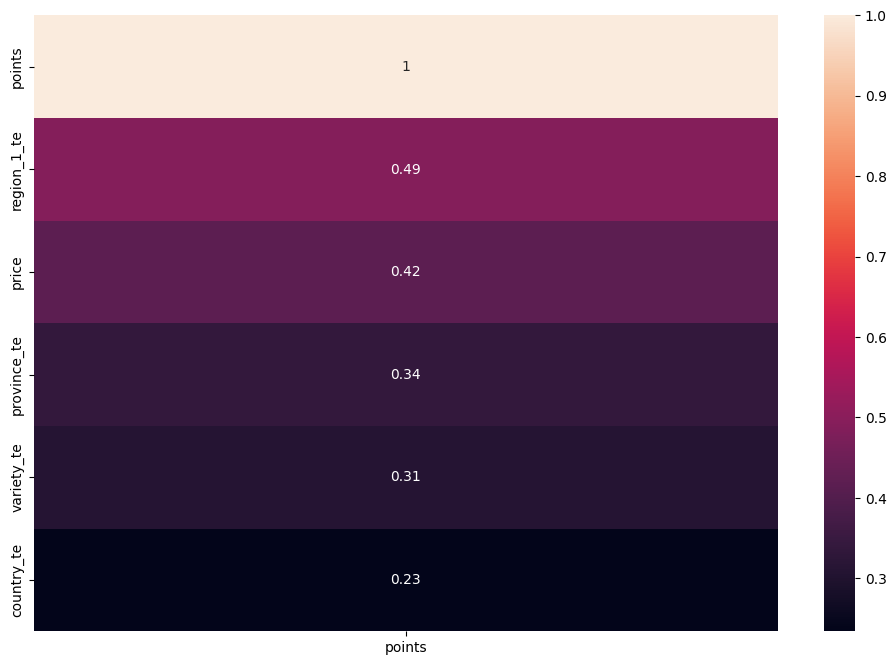

In [68]:
plt.figure(figsize=(12,8))
sns.heatmap(train_df.corr(numeric_only=True)[["points"]].sort_values(by='points', ascending=False), annot=True)

## 5.4. Model Building - Decision Tree Regressor

In [69]:
X_train = train_df.drop(columns=['points'])
y_train = train_df['points']

X_test = test_df.drop(columns=['points'])
y_test = test_df['points']

In [70]:
model = DecisionTreeRegressor(
    max_depth=None,
    random_state=42
)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
print("RMSE:", rmse)

r2 = r2_score(y_test, y_pred)
print("R2 Score:", r2)

RMSE: 2.205942723263958
R2 Score: 0.5092102825963204


## 5.5. Evaluation

After experimenting with high-dimensional One-Hot Encoding, I applied **Target Encoding** to handle the four high-cardinality categorical features:

- Province  
- Country  
- Region_1  
- Variety  

This approach reduces dimensionality by replacing each category with the mean target value of that category (calculated only from the training set to avoid data leakage).

---

### 🔹 Model Performance with Target Encoding

- Total Features: 6  
- RMSE: 2.206  
- R² Score: 0.509  

Compared to the best One-Hot Encoding configuration:

| Encoding Method | # Features | RMSE | R² |
|----------------|-----------|------|------|
| OHE (min_freq=10) | 2,589 | 2.186 | 0.518 |
| Target Encoding | 6 | 2.206 | 0.509 |

---

### 🔍 Interpretation

Target Encoding dramatically reduced the number of features (from 2,589 to only 6), while maintaining a very similar performance level.

Although One-Hot Encoding with fine granularity achieved slightly better performance, the improvement was marginal relative to the substantial increase in dimensionality and computational cost.

This suggests:

- High-cardinality categorical features do contain predictive signal.
- However, increasing granularity yields diminishing returns.
- The overall performance ceiling of the dataset may be limited by the intrinsic variance of the target variable.

Given that the target range is relatively narrow (80–100), achieving an RMSE around 2.2 indicates that the model captures a meaningful portion of the available signal.

---

### 📌 Conclusion

Model choice and encoding strategy both influence performance, but improvements remain incremental.  

This suggests that further gains may require:
- More advanced feature engineering  
- Feature interactions  
- Or alternative boosting-based models  

Rather than simply increasing model complexity or feature dimensionality.

# 6. Optimalize other feature - "Price" column
## 6.1. EDA : Price - Distribution

<Axes: xlabel='price', ylabel='Count'>

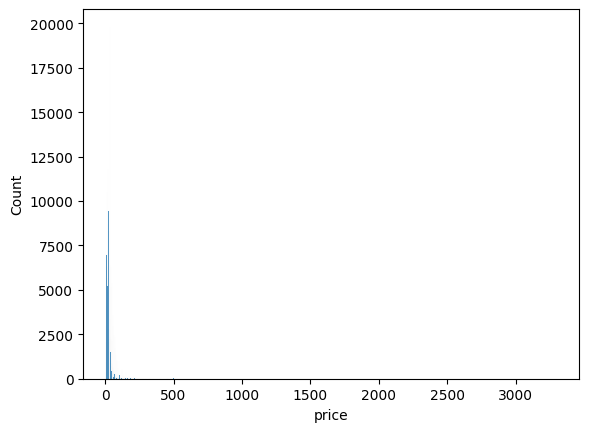

In [71]:
sns.histplot(train_df['price'])

## 6.2. EDA : Price - Percentile

In [72]:
train_df['price'].describe(percentiles=[0.5, 0.75, 0.9, 0.95, 0.99])

count    224720.000000
mean         34.197935
std          37.223066
min           4.000000
50%          27.000000
75%          40.000000
90%          60.000000
95%          80.000000
99%         150.000000
max        3300.000000
Name: price, dtype: float64

## 6.3. EDA : Price - Skewness

In [73]:
train_df['price'].skew()

np.float64(16.252987990363664)

So it has extreem skewness (16), the normal skewness is 0-2.

## 6.4. Feature Engineering : Price - Log Transform

In [74]:
train_df['log_price'] = np.log1p(train_df['price'])
test_df['log_price'] = np.log1p(test_df['price'])

<Axes: xlabel='log_price', ylabel='Count'>

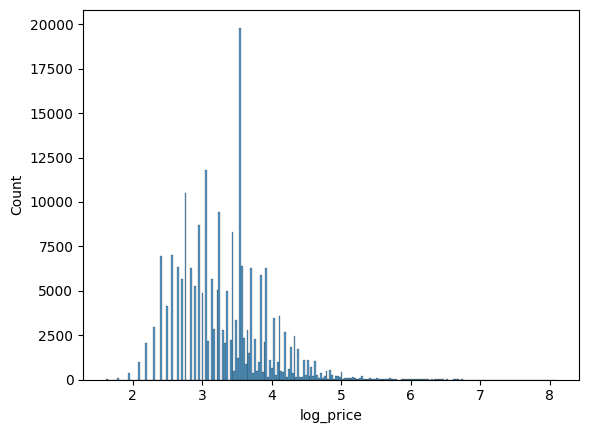

In [75]:
sns.histplot(train_df['log_price'])

In [76]:
(f'Skewness after log transform : {train_df['log_price'].skew()}')

'Skewness after log transform : 0.5896521096906171'

## 6.5. Model Building - Decision Tree Regressor (Tree Based)

In [77]:
X_train = train_df.drop(columns=['points','price'])
y_train = train_df['points']

X_test = test_df.drop(columns=['points','price'])
y_test = test_df['points']

In [78]:
model = DecisionTreeRegressor(
    max_depth=None,
    random_state=42
)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
print("RMSE:", rmse)

r2 = r2_score(y_test, y_pred)
print("R2 Score:", r2)

RMSE: 2.205780622260535
R2 Score: 0.5092824101105382


## 6.6. Model Building - Ridge (Non Tree Based)

In [79]:
from sklearn.linear_model import Ridge

model = Ridge(alpha=1.0)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
print("RMSE:", rmse)

r2 = r2_score(y_test, y_pred)
print("R2 Score:", r2)

RMSE: 2.4428007993036065
R2 Score: 0.39815715992301415


## 6.7. Model Building - Gradient Boosting (Non Tree Based)

In [80]:
model = HistGradientBoostingRegressor(random_state=42)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
print("RMSE:", rmse)

r2 = r2_score(y_test, y_pred)
print("R2 Score:", r2)

RMSE: 2.3115633383907146
R2 Score: 0.4610870904254566


## 6.8. Evaluation 
Although the price variable exhibited extreme skewness, applying log transformation did not improve model performance.
This suggests that tree-based models were already robust to the skewed distribution, and the price–points relationship may not require nonlinear scaling.

# 7. Optimalize Other Feature - "Winery" feature

In Section 2.9 (Insight Summary), several features were dropped due to their high cardinality.

However, instead of removing them entirely, we can apply specific encoding techniques to handle high-cardinality categorical features.

## 7.1. Feature Selection

In [81]:
df_raw.head()

,Unnamed: 0,country,description,designation,points,price,province,region_1,region_2,variety,winery,taster_name,taster_twitter_handle,title
0,0,US,This tremendous 100% varietal wine hails from ...,Martha's Vineyard,96,235.0,California,Napa Valley,Napa,Cabernet Sauvignon,Heitz,NaN,NaN,NaN
1,1,Spain,"Ripe aromas of fig, blackberry and cassis are ...",Carodorum Selección Especial Reserva,96,110.0,Northern Spain,Toro,NaN,Tinta de Toro,Bodega Carmen Rodríguez,NaN,NaN,NaN
2,2,US,Mac Watson honors the memory of a wine once ma...,Special Selected Late Harvest,96,90.0,California,Knights Valley,Sonoma,Sauvignon Blanc,Macauley,NaN,NaN,NaN
3,3,US,"This spent 20 months in 30% new French oak, an...",Reserve,96,65.0,Oregon,Willamette Valley,Willamette Valley,Pinot Noir,Ponzi,NaN,NaN,NaN
4,4,France,"This is the top wine from La Bégude, named aft...",La Brûlade,95,66.0,Provence,Bandol,NaN,Provence red blend,Domaine de la Bégude,NaN,NaN,NaN


In [82]:
# DROP
df = df_raw.drop(columns=['description', 'designation', 'region_2', 'taster_name', 'taster_twitter_handle', 'title', 'Unnamed: 0'])
df.head()

,country,points,price,province,region_1,variety,winery
0,US,96,235.0,California,Napa Valley,Cabernet Sauvignon,Heitz
1,Spain,96,110.0,Northern Spain,Toro,Tinta de Toro,Bodega Carmen Rodríguez
2,US,96,90.0,California,Knights Valley,Sauvignon Blanc,Macauley
3,US,96,65.0,Oregon,Willamette Valley,Pinot Noir,Ponzi
4,France,95,66.0,Provence,Bandol,Provence red blend,Domaine de la Bégude


## 7.2. Dataset train-test-split

In [83]:
train_df, test_df = train_test_split(
    df,
    test_size=0.2,
    random_state=42
)

## 7.3. Feature Engineering : Categorial Feature (Country, Province, Region_1, Variety, Winery) - Target Encoding
Let's convert Winery with Target Encoding Method.

In [84]:
# Get average of the price from train_df
mean_values = int(train_df["price"].mean())

# fill missing value on train & test
train_df["price"] = train_df["price"].fillna(mean_values)
test_df["price"]  = test_df["price"].fillna(mean_values)

In [85]:
train_te = train_df.copy()
test_te = test_df.copy()

cat_cols = ['province', 'country', 'region_1', 'variety', 'winery']
target_col = 'points'

# global mean
global_mean = train_te[target_col].mean()

for col in cat_cols:
    
    # fill missing category with unknown
    train_te[col] = train_te[col].fillna('Unknown')
    test_te[col] = test_te[col].fillna('Unknown')
    
    # determine mean of each category
    target_means = train_te.groupby(col)[target_col].mean()
    
    # mapping
    train_te[col + '_te'] = train_te[col].map(target_means)
    test_te[col + '_te'] = test_te[col].map(target_means)
    
    # fallback
    train_te[col + '_te'] = train_te[col + '_te'].fillna(global_mean)
    test_te[col + '_te'] = test_te[col + '_te'].fillna(global_mean)

# drop original categorial feature
train_te = train_te.drop(columns=cat_cols)
test_te = test_te.drop(columns=cat_cols)

In [86]:
# missing value checker
print(train_te.isna().sum())
print(test_te.isna().sum())

points         0
price          0
province_te    0
country_te     0
region_1_te    0
variety_te     0
winery_te      0
dtype: int64
points         0
price          0
province_te    0
country_te     0
region_1_te    0
variety_te     0
winery_te      0
dtype: int64


In [87]:
train_df = train_te
test_df = test_te
train_df.shape

(224720, 7)

## 7.4. Model Building - Decision Tree Regressor

In [88]:
X_train = train_df.drop(columns=['points'])
y_train = train_df['points']

X_test = test_df.drop(columns=['points'])
y_test = test_df['points']

In [89]:
model = DecisionTreeRegressor(
    max_depth=None,
    random_state=42
)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
print("RMSE:", rmse)

r2 = r2_score(y_test, y_pred)
print("R2 Score:", r2)

RMSE: 1.9573581239520954
R2 Score: 0.613590694261352


Compare `y_test` and `y_pred` by selecting samples with the highest prediction error.

In [90]:
comparison_df = pd.DataFrame({
    'y_test': y_test.values,
    'y_pred': y_pred
})

comparison_df['error'] = comparison_df['y_test'] - comparison_df['y_pred']
comparison_df.head(10)

comparison_df['abs_error'] = comparison_df['error'].abs()
comparison_df.sort_values('abs_error', ascending=False).head()

,y_test,y_pred,error,abs_error
54451,83,97.0,-14.0,14.0
28,95,82.0,13.0,13.0
23909,80,93.0,-13.0,13.0
5575,83,95.0,-12.0,12.0
14981,95,83.0,12.0,12.0


<Axes: >

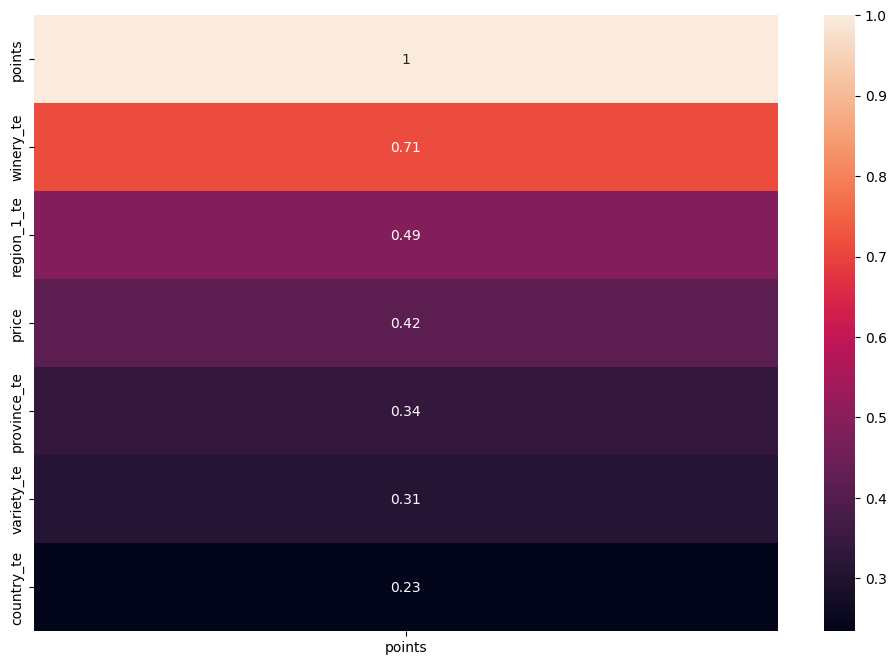

In [91]:
plt.figure(figsize=(12,8))
sns.heatmap(train_df.corr(numeric_only=True)[["points"]].sort_values(by='points', ascending=False), annot=True)

## 7.5. Evaluation 

In the previous experiments, most high-cardinality features were dropped due to the large number of unique values and the computational cost of One-Hot Encoding. However, this decision might remove potentially useful information from the dataset.

One of the features that was previously removed is **`winery`**, which contains a large number of unique values. Instead of dropping this feature, we experiment with **Target Encoding** to capture the relationship between each winery and the target variable (`points`).

Target Encoding replaces each category with the **mean target value of that category**, allowing us to preserve useful information while keeping the number of features small.

### Experiment Result

After applying Target Encoding to the `winery` feature and retraining the model, the performance improved:

| Model Metric | Before Adding Winery | After Adding Winery |
|---------------|---------------------|---------------------|
| RMSE | ~2.20 | **1.95** |
| R² Score | ~0.50 | **0.61** |

### Interpretation

The improvement in performance suggests that the **winery feature carries meaningful predictive information**. This is reasonable from a domain perspective, since wineries often have different production standards, reputations, and wine styles that may influence the final rating.

By using Target Encoding, we are able to incorporate this high-cardinality feature without dramatically increasing the dimensionality of the dataset.

### Decision

Based on this experiment:

- The **`winery` feature will be kept** in the model.
- The feature will be encoded using **Target Encoding** instead of One-Hot Encoding.
- This approach balances **information preservation and computational efficiency**.

This result also suggests that some high-cardinality categorical features may still be valuable when encoded with appropriate techniques.

# 8. Optimalize Other Feature - "Designation" feature
## 8.1. Feature Selection

In [92]:
df_raw.head()

,Unnamed: 0,country,description,designation,points,price,province,region_1,region_2,variety,winery,taster_name,taster_twitter_handle,title
0,0,US,This tremendous 100% varietal wine hails from ...,Martha's Vineyard,96,235.0,California,Napa Valley,Napa,Cabernet Sauvignon,Heitz,NaN,NaN,NaN
1,1,Spain,"Ripe aromas of fig, blackberry and cassis are ...",Carodorum Selección Especial Reserva,96,110.0,Northern Spain,Toro,NaN,Tinta de Toro,Bodega Carmen Rodríguez,NaN,NaN,NaN
2,2,US,Mac Watson honors the memory of a wine once ma...,Special Selected Late Harvest,96,90.0,California,Knights Valley,Sonoma,Sauvignon Blanc,Macauley,NaN,NaN,NaN
3,3,US,"This spent 20 months in 30% new French oak, an...",Reserve,96,65.0,Oregon,Willamette Valley,Willamette Valley,Pinot Noir,Ponzi,NaN,NaN,NaN
4,4,France,"This is the top wine from La Bégude, named aft...",La Brûlade,95,66.0,Provence,Bandol,NaN,Provence red blend,Domaine de la Bégude,NaN,NaN,NaN


In [93]:
# DROP
df = df_raw.drop(columns=['description', 'region_2', 'taster_name', 'taster_twitter_handle', 'title', 'Unnamed: 0'])
df.head()

,country,designation,points,price,province,region_1,variety,winery
0,US,Martha's Vineyard,96,235.0,California,Napa Valley,Cabernet Sauvignon,Heitz
1,Spain,Carodorum Selección Especial Reserva,96,110.0,Northern Spain,Toro,Tinta de Toro,Bodega Carmen Rodríguez
2,US,Special Selected Late Harvest,96,90.0,California,Knights Valley,Sauvignon Blanc,Macauley
3,US,Reserve,96,65.0,Oregon,Willamette Valley,Pinot Noir,Ponzi
4,France,La Brûlade,95,66.0,Provence,Bandol,Provence red blend,Domaine de la Bégude


## 8.2. Dataset train-test-split

In [94]:
train_df, test_df = train_test_split(
    df,
    test_size=0.2,
    random_state=42
)

## 8.3. Feature Engineering : Categorial Feature (Country, Province, Region_1, Variety, Winery, Designation) - Target Encoding
Let's convert Winery with Target Encoding Method.

In [95]:
# Get average of the price from train_df
mean_values = int(train_df["price"].mean())

# fill missing value on train & test
train_df["price"] = train_df["price"].fillna(mean_values)
test_df["price"]  = test_df["price"].fillna(mean_values)


In [96]:
train_te = train_df.copy()
test_te = test_df.copy()

cat_cols = ['province', 'country', 'region_1', 'variety', 'winery', 'designation']
target_col = 'points'

# global mean
global_mean = train_te[target_col].mean()

for col in cat_cols:
    
    # fill missing category with unknown
    train_te[col] = train_te[col].fillna('Unknown')
    test_te[col] = test_te[col].fillna('Unknown')
    
    # determine mean of each category
    target_means = train_te.groupby(col)[target_col].mean()
    
    # mapping
    train_te[col + '_te'] = train_te[col].map(target_means)
    test_te[col + '_te'] = test_te[col].map(target_means)
    
    # fallback
    train_te[col + '_te'] = train_te[col + '_te'].fillna(global_mean)
    test_te[col + '_te'] = test_te[col + '_te'].fillna(global_mean)

# drop original categorial feature
train_te = train_te.drop(columns=cat_cols)
test_te = test_te.drop(columns=cat_cols)


In [97]:
# missing value checker
print(train_te.isna().sum())
print(test_te.isna().sum())

points            0
price             0
province_te       0
country_te        0
region_1_te       0
variety_te        0
winery_te         0
designation_te    0
dtype: int64
points            0
price             0
province_te       0
country_te        0
region_1_te       0
variety_te        0
winery_te         0
designation_te    0
dtype: int64


In [98]:
train_df = train_te
test_df = test_te
train_df.shape

(224720, 8)

## 8.4. Model Building - Decision Tree Regressor 

In [99]:
X_train = train_df.drop(columns=['points'])
y_train = train_df['points']

X_test = test_df.drop(columns=['points'])
y_test = test_df['points']

In [100]:
model = DecisionTreeRegressor(
    max_depth=None,
    random_state=42
)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
print("RMSE:", rmse)

r2 = r2_score(y_test, y_pred)
print("R2 Score:", r2)

RMSE: 1.9275046786623768
R2 Score: 0.6252877655343574


<Axes: >

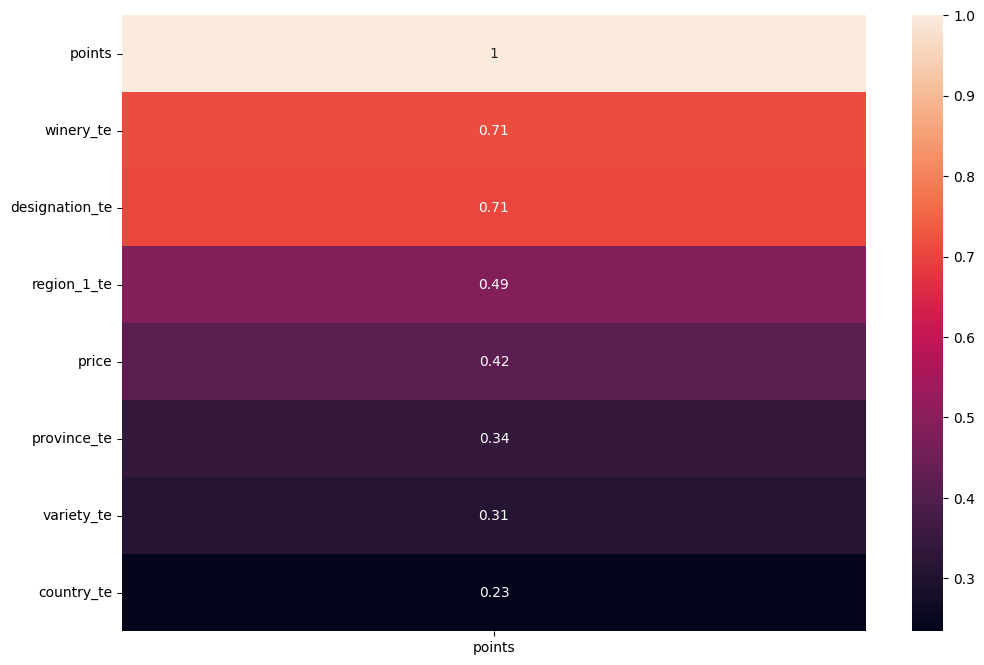

In [101]:
plt.figure(figsize=(12,8))
sns.heatmap(train_df.corr(numeric_only=True)[["points"]].sort_values(by='points', ascending=False), annot=True)

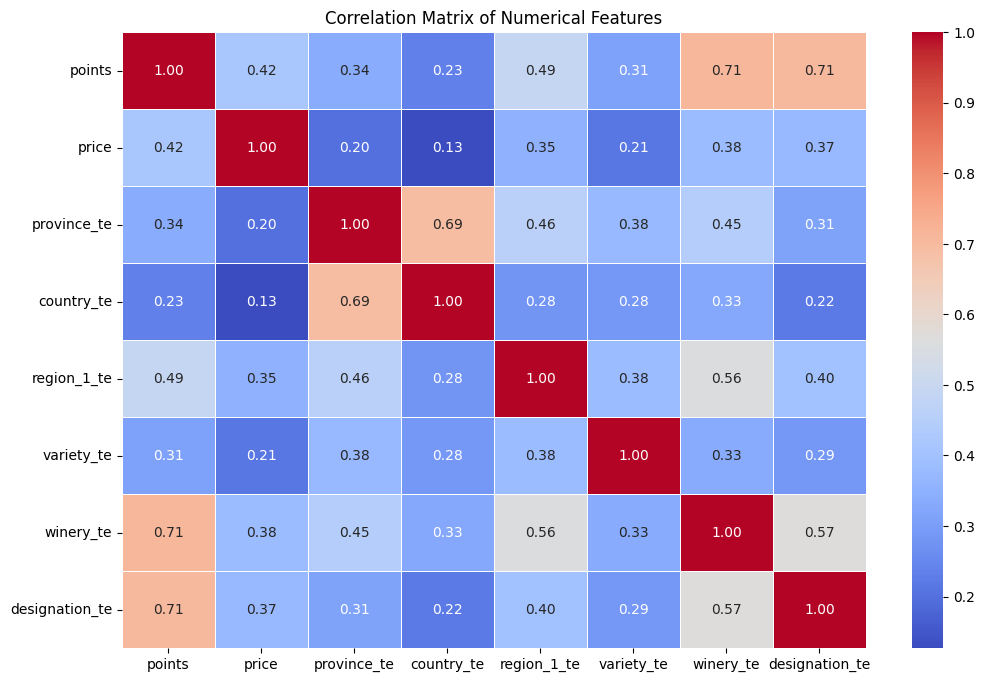

In [102]:
plt.figure(figsize=(12,8))

corr_matrix = train_df.corr(numeric_only=True)

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap='coolwarm',
    fmt=".2f",
    linewidths=0.5
)

plt.title("Correlation Matrix of Numerical Features")
plt.show()

Although both `winery` and `designation` show a similar correlation
with the target variable (≈0.71), their contribution to the model
performance is different.

After adding `winery`, the model performance improved significantly.
However, adding `designation` only produced a small improvement.

This suggests that part of the information contained in `designation`
is already captured by `winery`. The correlation between these two
features (~0.57) indicates that they share overlapping information.

Therefore, while `designation` still provides additional signal,
its marginal contribution is smaller compared to `winery`.

## 8.5. Evaluation

Previously, we added the **`winery`** feature using **Target Encoding**, which significantly improved the model performance.  
This suggests that producer-related information carries strong signals about wine quality.

To further investigate this pattern, we also applied **Target Encoding** to the **`designation`** feature.

`designation` usually represents the specific product label or classification of the wine (e.g., Reserve, Estate, Special Selection). This information may indicate the **product tier or quality level** within a winery.

After adding `designation_te` to the model, we obtained the following results:

- **RMSE:** 1.9275  
- **R² Score:** 0.6253  

Compared to the previous model (without `designation`):

- RMSE improved from **1.957 → 1.927**
- R² increased from **0.613 → 0.625**

Although the improvement is relatively small compared to the addition of `winery`, the feature still contributes positively to the model performance.

Further analysis shows:

- `winery_te` and `designation_te` both have a strong correlation with the target (`points`)
- Their correlation with each other is **moderate (~0.57)**, meaning they capture **related but not identical information**

Feature importance from the model also confirms that both features play a major role in prediction.

### Decision

Because `designation` provides **additional predictive signal** and improves model performance without introducing severe multicollinearity, we **decide to keep this feature in the final model**.

# 9. Optimalize Other feature - "Description" feature